In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("03-2023.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,31910814822,2023-03-01 04:07,NaN,00:01:17,NaN,Karen Parker
1,31911226501,2023-03-01 04:08,NaN,00:01:13,NaN,Karen Parker
2,31921670559,2023-03-01 08:29,NaN,00:13:13,NaN,Travis Fleming
3,31923361399,2023-03-01 09:11,NaN,00:41:08,NaN,Ray Levesque
4,31924760337,2023-03-01 09:25,NaN,00:00:43,NaN,Paol Guzman


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10821 entries, 0 to 10820
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             10821 non-null  int64  
 1   Activity date         10821 non-null  str    
 2   Call direction        377 non-null    str    
 3   Call duration         10017 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  10821 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 896.6 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10821 entries, 0 to 10820
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10821 non-null  datetime64[us]
 1   Call direction        377 non-null    str           
 2   Call duration         10017 non-null  str           
 3   Activity assigned to  10821 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 558.4 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-03-01 04:07:00,NaN,00:01:17,Karen Parker,2023-03-01
1,2023-03-01 04:08:00,NaN,00:01:13,Karen Parker,2023-03-01
2,2023-03-01 08:29:00,NaN,00:13:13,Travis Fleming,2023-03-01
3,2023-03-01 09:11:00,NaN,00:41:08,Ray Levesque,2023-03-01
4,2023-03-01 09:25:00,NaN,00:00:43,Paol Guzman,2023-03-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2023-03-01,284
1,2023-03-02,262
2,2023-03-03,359
3,2023-03-04,21
4,2023-03-05,8


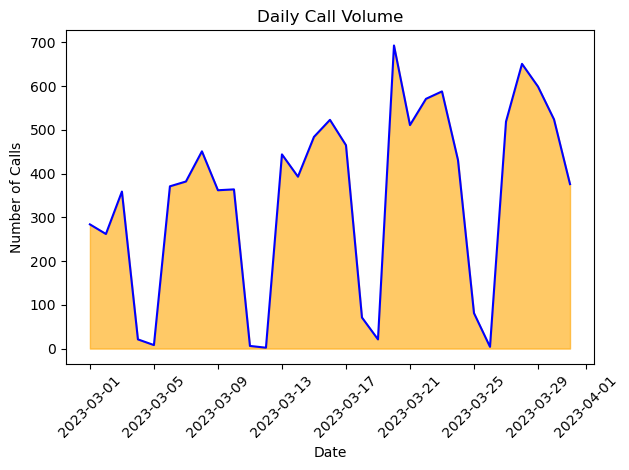

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [29]:
df1['day'] = df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-03-01 04:07:00,NaN,00:01:17,Karen Parker,Wednesday
1,2023-03-01 04:08:00,NaN,00:01:13,Karen Parker,Wednesday
2,2023-03-01 08:29:00,NaN,00:13:13,Travis Fleming,Wednesday
3,2023-03-01 09:11:00,NaN,00:41:08,Ray Levesque,Wednesday
4,2023-03-01 09:25:00,NaN,00:00:43,Paol Guzman,Wednesday


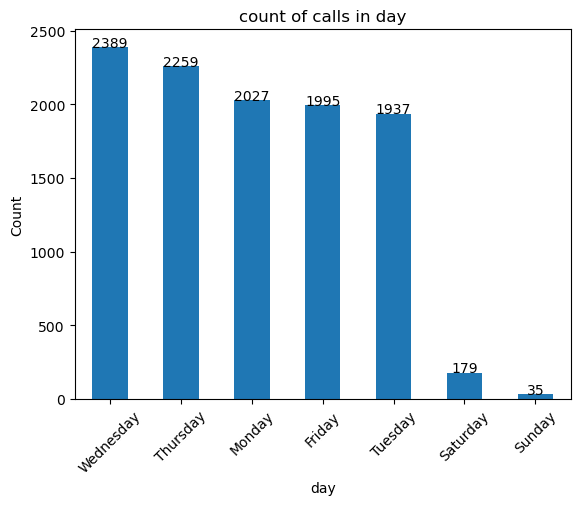

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

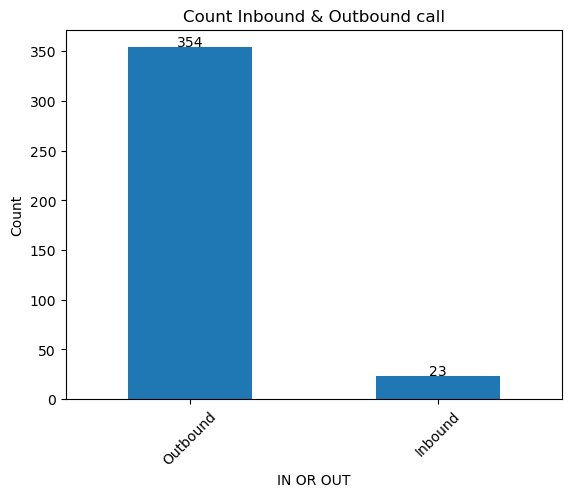

In [36]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [39]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

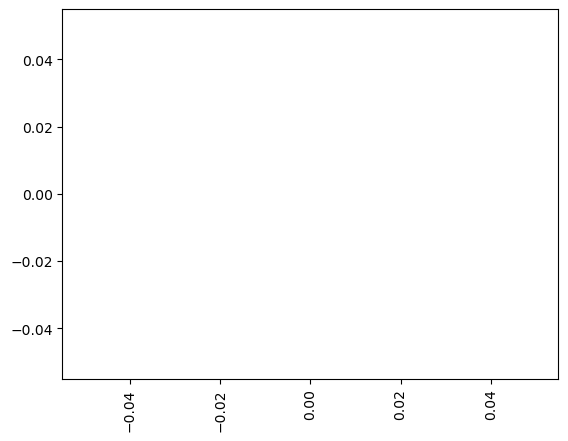

In [41]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration Null but have Call direction

In [44]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
29,2023-03-01 11:10:00,Outbound,NaN,Keith Antonio,Wednesday
556,2023-03-03 09:54:00,Outbound,NaN,Jinky Rance,Friday
717,2023-03-03 13:30:00,Outbound,NaN,Jinky Rance,Friday
843,2023-03-03 16:29:00,Outbound,NaN,Jinky Rance,Friday
1041,2023-03-06 12:34:00,Outbound,NaN,Keith Antonio,Monday
1111,2023-03-06 13:58:00,Outbound,NaN,Keith Antonio,Monday
1112,2023-03-06 13:59:00,Outbound,NaN,Keith Antonio,Monday
1340,2023-03-07 11:30:00,Outbound,NaN,Keith Antonio,Tuesday
1344,2023-03-07 11:32:00,Outbound,NaN,Keith Antonio,Tuesday
1350,2023-03-07 11:34:00,Outbound,NaN,Keith Antonio,Tuesday


In [46]:
df4 = df1.copy()

In [48]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-03-01 04:07:00,NaN,00:01:17,Karen Parker,Wednesday
1,2023-03-01 04:08:00,NaN,00:01:13,Karen Parker,Wednesday
2,2023-03-01 08:29:00,NaN,00:13:13,Travis Fleming,Wednesday
3,2023-03-01 09:11:00,NaN,00:41:08,Ray Levesque,Wednesday
4,2023-03-01 09:25:00,NaN,00:00:43,Paol Guzman,Wednesday


In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

0

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

57

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 377 entries, 29 to 10775
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         377 non-null    datetime64[us]
 1   Call direction        377 non-null    str           
 2   Call duration         377 non-null    float64       
 3   Activity assigned to  377 non-null    str           
 4   day                   377 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 27.8 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

19

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'Karen Parker',      'Travis Fleming',        'Ray Levesque',
         'Paol Guzman',      'Cameron Dudley',        'Dioni Canega',
       'Tommie Walker',      'David Banister',        'Andy Ramirez',
       'Keith Antonio',         'Jinky Rance',        'David Valdez',
         'Adrian Tran',           'Terry Kim',    'Vladimir Suparto',
     'Ra’Saan Daniels', 'Demmie Rose Tamonan',          'Daniel Uli',
    'Chrystel Manabat']
Length: 19, dtype: str

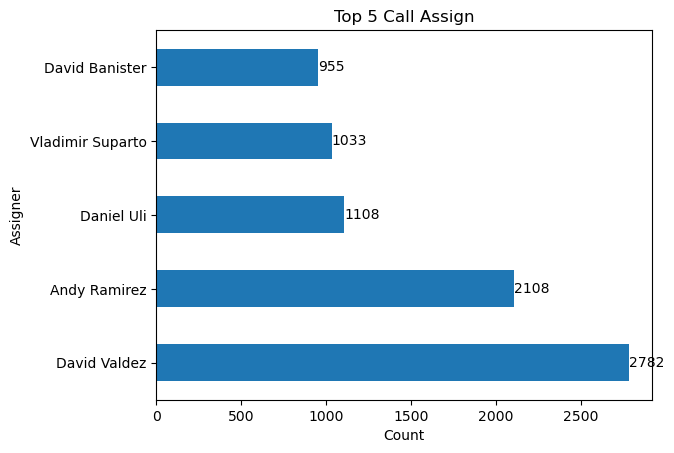

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

95.3

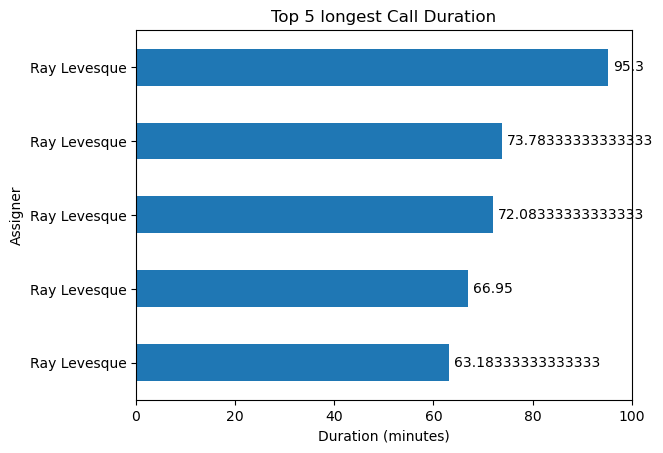

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [75]:
df3 = df1.copy()

In [77]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [79]:
df3['day'].unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']
Length: 5, dtype: str

In [81]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

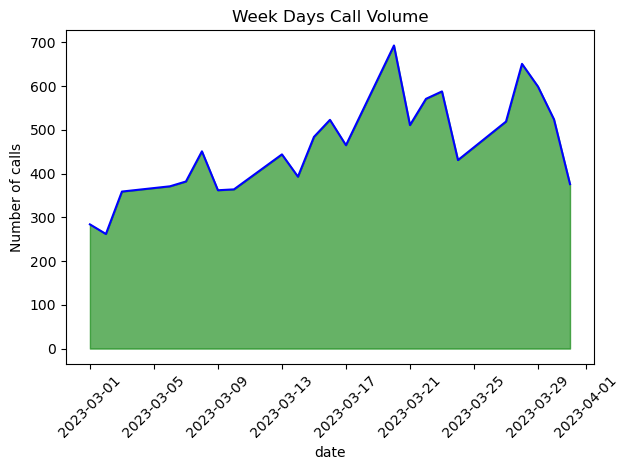

In [83]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [86]:
df5=df4.copy()

In [88]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [90]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
906,2023-03-04 11:50:00,Outbound,1.250000,Ray Levesque,Saturday
918,2023-03-04 16:20:00,Outbound,26.266667,Ray Levesque,Saturday
2864,2023-03-11 09:01:00,Outbound,22.816667,Ray Levesque,Saturday
2865,2023-03-11 09:25:00,Outbound,1.933333,Ray Levesque,Saturday
2868,2023-03-11 16:02:00,Outbound,1.066667,Ray Levesque,Saturday


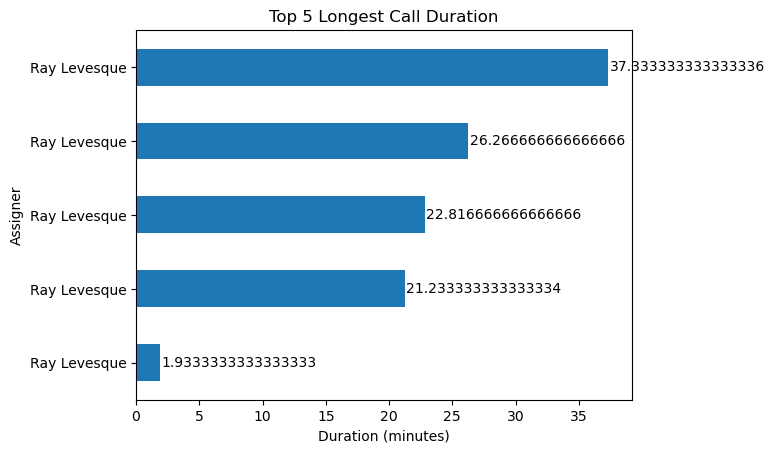

In [92]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

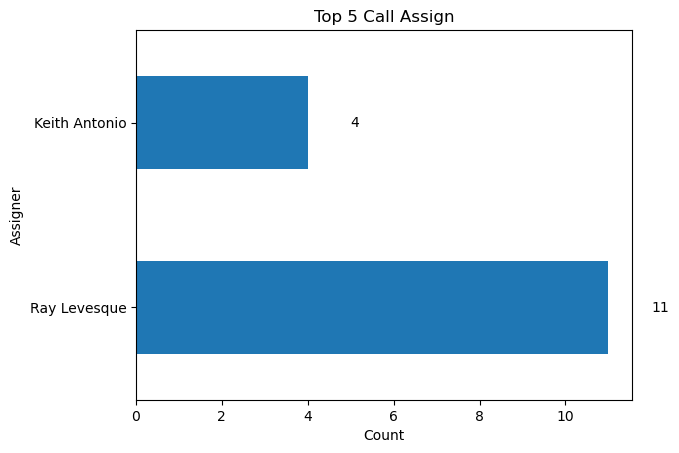

In [95]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [98]:
df4["Call duration"].mean()

6.136206896551725

In [100]:
df4["Call duration"].median()

1.2166666666666666

# Without Call Assigner Calls

In [103]:
df6 = df3.copy()

In [105]:
df6['month'] = df6['Activity date'].dt.month_name()

In [107]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

IndexError: index 0 is out of bounds for axis 0 with size 0

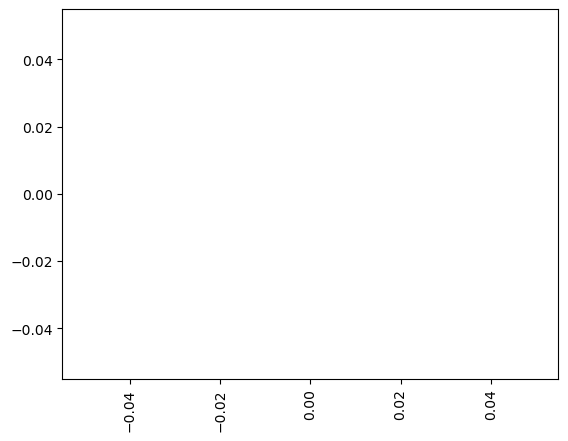

In [109]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call date 

In [112]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [114]:
top5 = daily_calls.sort_values(ascending=False).head(5)

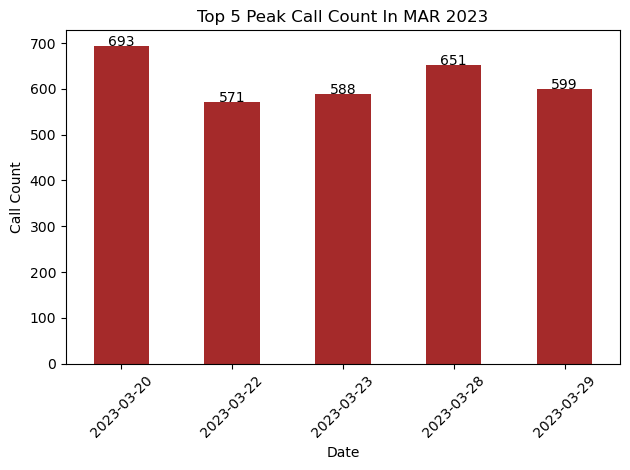

In [118]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In MAR 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()